In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import kmedoids 
import chemiscope
import seaborn as sns
import pandas as pd

from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from tqdm import tqdm

from src.datasets import QM9Dataset
from src.features import get_features_xyz, get_raw_xyz_features
from src.non_euclidean import Grassmann, Riemann, PersistentHomology, Wasserstein
from src.helper_functions import align_frames_to_dist_matrix, get_distances

In [3]:
qm9 = QM9Dataset()
qm9.load()
frames = qm9.get_positions(invariant=True)

2026-03-11 14:37:35.740 | INFO     | src.datasets:load:109 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-11 14:37:36.562 | DEBUG    | src.datasets:get_positions:597 - Skipping qm9_686: Embedding failed.
2026-03-11 14:37:37.259 | DEBUG    | src.datasets:get_positions:597 - Skipping qm9_1332: Embedding failed.
2026-03-11 14:37:38.861 | SUCCESS  | src.datasets:get_positions:605 - Saved 1998 molecules to data/QM9/qm9_subset.xyz (failed: 2, requested: 2000).


In [4]:
print(frames)

[Atoms(symbols='HCH3', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='HNH2', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='HOH', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H2C2', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='HNC', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H2CO', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H2C2H4', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H2OCH2', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3C3H', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3C2N', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3COCH', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3CON', pbc=False, initial_charges=..., mas

In [5]:
distance_matrices = get_distances(frames)

2026-03-11 14:37:38.903 | INFO     | src.helper_functions:get_distances:132 - Computing grassmann_qr distance matrix...
2026-03-11 14:37:38.904 | INFO     | src.non_euclidean:distance_matrix:268 - Computing Grassmann distance matrix for 1998 frames (k=3, method='qr').
Grassmann distances: 100%|██████████| 1995003/1995003 [02:25<00:00, 13680.88pair/s]
2026-03-11 14:40:04.968 | SUCCESS  | src.non_euclidean:distance_matrix:287 - Finished Grassmann distance matrix computation.
2026-03-11 14:40:04.977 | INFO     | src.helper_functions:get_distances:132 - Computing grassmann_svd distance matrix...
2026-03-11 14:40:04.977 | INFO     | src.non_euclidean:distance_matrix:268 - Computing Grassmann distance matrix for 1998 frames (k=3, method='svd').
Grassmann distances: 100%|██████████| 1995003/1995003 [02:24<00:00, 13787.92pair/s]
2026-03-11 14:42:29.778 | SUCCESS  | src.non_euclidean:distance_matrix:287 - Finished Grassmann distance matrix computation.
2026-03-11 14:42:29.787 | INFO     | src.h

In [6]:
distance_matrices['wasserstein'].shape

(1999, 1999)

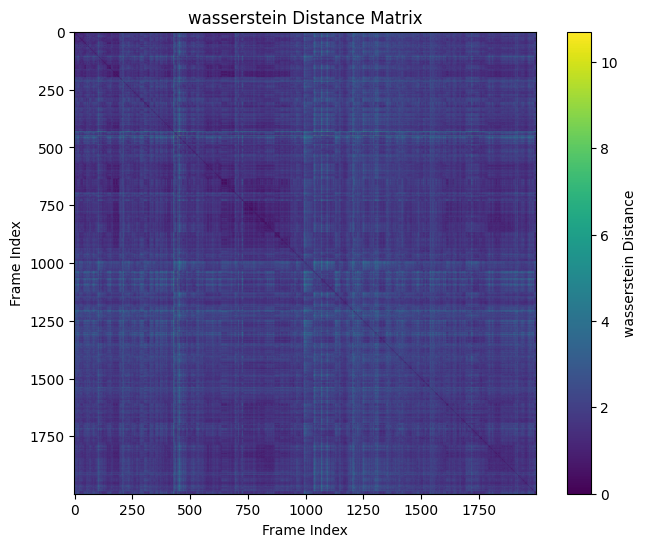

In [7]:
def show_distance_matrix(distance_matrix, method):
    plt.figure(figsize=(8, 6))
    plt.imshow(distance_matrix, cmap='viridis')
    plt.colorbar(label=f'{method} Distance')
    plt.title(f"{method} Distance Matrix")
    plt.xlabel("Frame Index")
    plt.ylabel("Frame Index")
    plt.show()

show_distance_matrix(distance_matrices['wasserstein'], 'wasserstein')

In [44]:
def build_cluster_analysis_df(frames, cluster_labels):
    """Build a per-frame dataframe used for cluster composition/property analysis."""
    return pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": [f.info.get('mol_id', '') for f in frames],
        "smiles": [f.info.get('smiles', '') for f in frames],
        "structure_type": [f.info.get('structure_type', '') for f in frames],
        "functional_groups": [f.info.get('functional_groups', '') for f in frames],
        "heavy_atom_count": [f.info.get('heavy_atom_count', None) for f in frames],
        "element_ratio_C": [f.info.get('element_ratio_C', None) for f in frames],
        "element_ratio_N": [f.info.get('element_ratio_N', None) for f in frames],
        "element_ratio_O": [f.info.get('element_ratio_O', None) for f in frames],
        "element_ratio_F": [f.info.get('element_ratio_F', None) for f in frames],
        "mu": [f.info.get('mu', None) for f in frames],
        "gap": [f.info.get('gap', None) for f in frames],
        "cv": [f.info.get('cv', None) for f in frames],
        "u0": [f.info.get('u0', None) for f in frames],
        "homo": [f.info.get('homo', None) for f in frames],
        "lumo": [f.info.get('lumo', None) for f in frames],
        # Newly added structural and derived columns
        "num_atoms": [f.info.get('num_atoms', len(f)) for f in frames],
        "total_mass": [f.info.get('total_mass', f.get_masses().sum()) for f in frames],
        "mean_partial_charge": [f.info.get('mean_partial_charge', None) for f in frames],
        "branching_index": [f.info.get('branching_index', None) for f in frames],
        "num_sp_carbons": [f.info.get('num_sp_carbons', None) for f in frames],
        "num_sp2_carbons": [f.info.get('num_sp2_carbons', None) for f in frames],
        "num_sp3_carbons": [f.info.get('num_sp3_carbons', None) for f in frames],
        "main_chain_length": [f.info.get('main_chain_length', None) for f in frames],
        "raw_token_count": [f.info.get('raw_token_count', None) for f in frames],
    })


def summarize_cluster_profiles(analysis_df, label_col='cluster'):
    """Per-cluster means/variances for size, elemental makeup, and QM9 quantum properties."""
    cols = [
        "heavy_atom_count",
        "element_ratio_C", "element_ratio_N", "element_ratio_O", "element_ratio_F",
        "mu", "gap", "cv", "u0", "homo", "lumo", 
        "num_atoms", "total_mass", "mean_particle_charge", "num_sp_carbons", "num_sp2_carbons", "num_sp3_carbons",
        "main_chain_length", "raw_token_count",
    ]
    valid_cols = [c for c in cols if c in analysis_df.columns]

    exprs = [pl.len().alias('n_samples')]
    for c in valid_cols:
        exprs.append(pl.col(c).cast(pl.Float64, strict=False).mean().alias(f"avg_{c}"))
        exprs.append(pl.col(c).cast(pl.Float64, strict=False).var().alias(f"var_{c}"))

    return analysis_df.group_by(label_col).agg(exprs).sort(label_col)

def evaluate_k_for_distance_matrices(
    distance_sets,
    k_range=range(2, 25),
    random_state=42,
    max_silhouette_samples=10_000,
    frames=None,
    return_cluster_profiles=False,
    algorithm='k_medoids',
):

    if algorithm not in ['k_medoids', 'spectral']:
        raise ValueError("algorithm must be either 'k_medoids' or 'spectral'")
        
    results = {name: {'inertia': [], 'silhouette': []} for name in distance_sets}

    for name, dist_matrix in list(distance_sets.items()):
        dist_matrix = np.asarray(dist_matrix)
        if dist_matrix.ndim != 2 or dist_matrix.shape[0] != dist_matrix.shape[1]:
            raise ValueError(f"Distance matrix '{name}' must be square. Got {dist_matrix.shape}.")

        if np.isnan(dist_matrix).any():
            print(f"Skipping '{name}': contains NaNs.")
            results.pop(name, None)
            continue

        n = dist_matrix.shape[0]
        valid_k = [k for k in k_range if 2 <= k < n]
        if not valid_k:
            raise ValueError(
                f"No valid k values for '{name}'. Need 2 <= k < n_samples (n={n})."
            )
            
        if algorithm == 'spectral':
            variance = np.var(dist_matrix)
            if variance == 0: variance = 1e-10
            affinity_matrix = np.exp(- (dist_matrix ** 2) / (2.0 * variance))

        progress_desc = f"Processing {name} (n={n}, algo={algorithm})"
        for k in tqdm(valid_k, desc=progress_desc):
            if algorithm == 'k_medoids':
                model = kmedoids.KMedoids(n_clusters=k, random_state=random_state)
                labels = model.fit_predict(dist_matrix)
                
                if hasattr(model, 'inertia_') and model.inertia_ is not None:
                    cost = float(model.inertia_)
                elif hasattr(model, 'error_'):
                    cost = float(model.error_)
                elif hasattr(model, 'medoid_indices_'):
                    medoids = model.medoid_indices_
                    cost = np.sum(np.min(dist_matrix[:, medoids], axis=1))
                else:
                    cost = np.nan
                    
            elif algorithm == 'spectral':
                model = SpectralClustering(
                    n_clusters=k, 
                    affinity='precomputed', 
                    random_state=random_state,
                    assign_labels='kmeans'
                )
                labels = model.fit_predict(affinity_matrix)
                cost = np.nan # Spectral clustering doesn't have a direct inertia metric

            results[name]['inertia'].append(cost)

            if n > max_silhouette_samples:
                sil = silhouette_score(
                    dist_matrix,
                    labels,
                    metric='precomputed',
                    sample_size=max_silhouette_samples,
                    random_state=random_state,
                )
            else:
                sil = silhouette_score(dist_matrix, labels, metric='precomputed')
            results[name]['silhouette'].append(float(sil))

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    for name, metrics in results.items():
        n = np.asarray(distance_sets[name]).shape[0]
        valid_k = [k for k in k_range if 2 <= k < n]
        ax1.plot(valid_k, metrics['inertia'], marker='o', label=name)

    algo_title_prefix = "K-Medoids" if algorithm == 'k_medoids' else "Spectral Clustering"
    ax1.set_title(f'{algo_title_prefix} Objective (Inertia)')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia (Elbow method)' if algorithm == 'k_medoids' else 'Inertia (N/A for Spectral)')
    ax1.legend()
    ax1.grid(True)

    for name, metrics in results.items():
        n = np.asarray(distance_sets[name]).shape[0]
        valid_k = [k for k in k_range if 2 <= k < n]
        ax2.plot(valid_k, metrics['silhouette'], marker='s', linestyle='--', label=name)

    ax2.set_title(f'{algo_title_prefix} Silhouette Score (Precomputed Distances)')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Silhouette Score (Higher is better)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # --- Summarize ---
    best_k = {}
    for name, metrics in results.items():
        if metrics['silhouette']:
            idx = int(np.argmax(metrics['silhouette']))
            ks = [k for k in k_range if 2 <= k < np.asarray(distance_sets[name]).shape[0]]
            best_k[name] = ks[idx]

    summary = pl.DataFrame(
        {
            'name': list(best_k.keys()),
            'best_k_by_silhouette': list(best_k.values()),
            'best_silhouette': [max(results[name]['silhouette']) for name in best_k],
        }
    )

    from IPython.display import display
    display(summary)

    # --- Cluster Profiles ---
    cluster_profiles = {}
    if return_cluster_profiles and frames is not None:
        for name, k in best_k.items():
            dist_matrix = np.asarray(distance_sets[name])
            active_frames = align_frames_to_dist_matrix(frames, dist_matrix=dist_matrix)
            
            # Refit with chosen algorithm
            if algorithm == 'k_medoids':
                labels = kmedoids.KMedoids(n_clusters=k, random_state=random_state).fit_predict(dist_matrix)
            elif algorithm == 'spectral':
                variance = np.var(dist_matrix)
                if variance == 0: variance = 1e-10
                affinity_matrix = np.exp(- (dist_matrix ** 2) / (2.0 * variance))
                labels = SpectralClustering(
                    n_clusters=k, 
                    affinity='precomputed', 
                    random_state=random_state,
                    assign_labels='kmeans'
                ).fit_predict(affinity_matrix)
                
            analysis_df = build_cluster_analysis_df(active_frames, labels)
            cluster_profiles[name] = summarize_cluster_profiles(analysis_df)

        if cluster_profiles:
            print()
            print("Per-cluster profile at best k (size/composition/QM properties):")
            for metric_name, profile_df in cluster_profiles.items():
                print()
                print(f"{metric_name}")
                display(profile_df)

    return results, summary, cluster_profiles



Processing grassmann_qr (n=1998, algo=k_medoids): 100%|██████████| 23/23 [00:02<00:00,  8.03it/s]
Processing grassmann_svd (n=1998, algo=k_medoids): 100%|██████████| 23/23 [00:02<00:00,  7.81it/s]
Processing euclidean_riemann (n=1999, algo=k_medoids): 100%|██████████| 23/23 [00:02<00:00,  9.08it/s]
Processing affine_riemann (n=1999, algo=k_medoids): 100%|██████████| 23/23 [00:02<00:00,  8.21it/s]
Processing wasserstein (n=1999, algo=k_medoids): 100%|██████████| 23/23 [00:02<00:00,  8.72it/s]
Processing ph_bottleneck (n=1999, algo=k_medoids): 100%|██████████| 23/23 [00:02<00:00,  8.98it/s]
Processing ph_sliced_wasserstein (n=1999, algo=k_medoids): 100%|██████████| 23/23 [00:01<00:00, 12.23it/s]


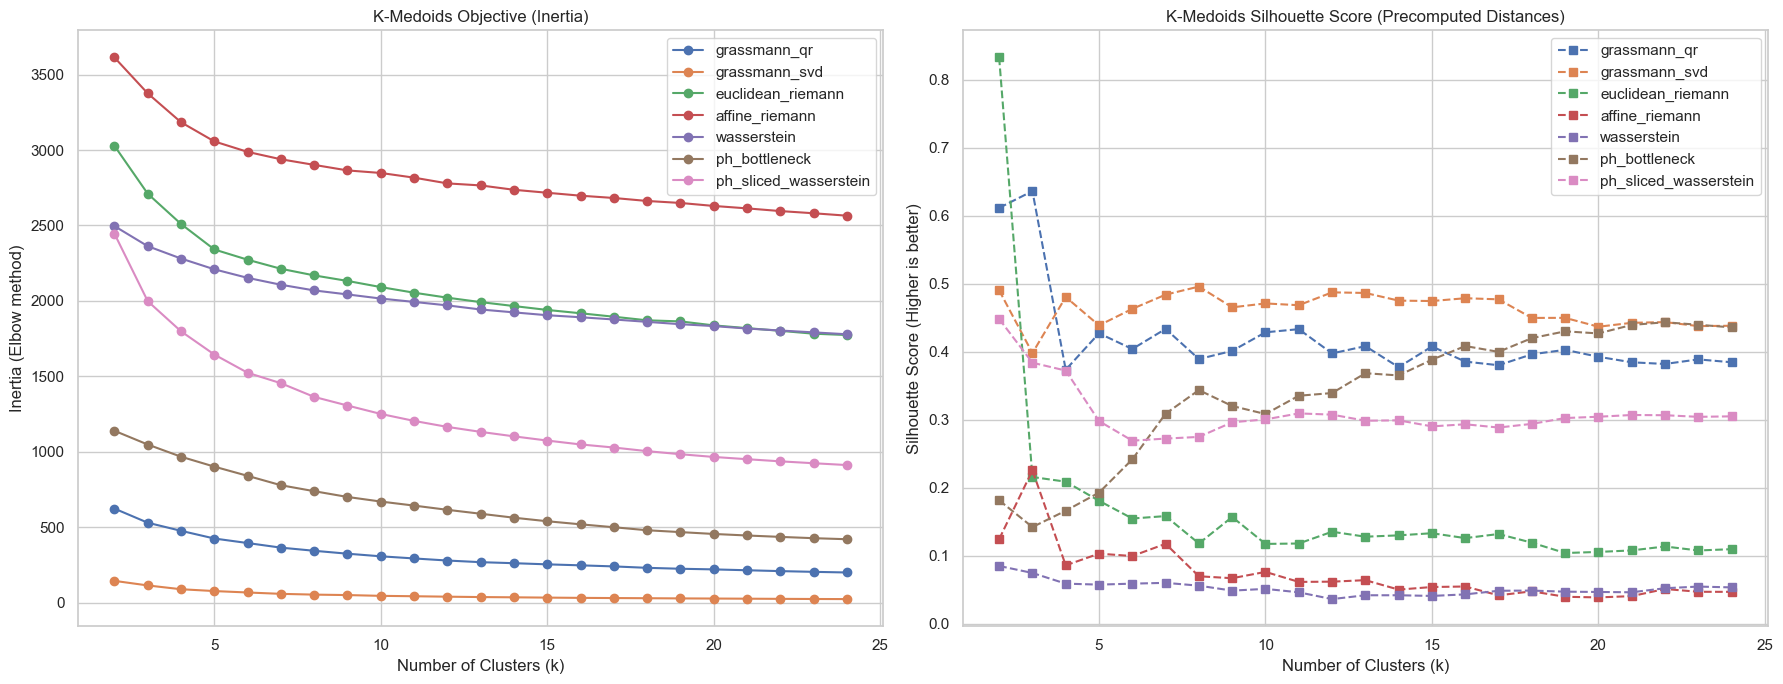

name,best_k_by_silhouette,best_silhouette
str,i64,f64
"""grassmann_qr""",3,0.636132
"""grassmann_svd""",8,0.495729
"""euclidean_riemann""",2,0.83263
"""affine_riemann""",3,0.225464
"""wasserstein""",2,0.084858
"""ph_bottleneck""",22,0.443263
"""ph_sliced_wasserstein""",2,0.448154


ValueError: frames has 1998 entries, but dist_matrix requires 1999.

In [47]:
results, summary, best_k_profiles = evaluate_k_for_distance_matrices(
    distance_matrices,
    frames=frames,
    return_cluster_profiles=True,
    algorithm='k_medoids'
)


# best number of clusters
- grassmann 2
- affine riemann 5
- euclidean riemann 5
- others 2
- ph-bottleneck 22

In [45]:
def make_clustering(frames, rotational_invariant=False, dist_matrix=None, metric_name="euclidean", num_clusters = 2):
    """
    Unified clustering function handling both feature matrices and precomputed distance matrices.
    """
    #active_frames = align_frames_to_dist_matrix(frames, dist_matrix=dist_matrix)
    active_frames = frames
    true_labels = [f.info.get('mol_id', '') for f in active_frames]
    smiles_list = [f.info.get('smiles', '') for f in active_frames]
    base_or_pertubated = [f.info.get('frame_type', 'base') for f in active_frames]
    structure = [f.info.get('structure_type', '') for f in active_frames]
    functional_groups = [f.info.get('functional_groups', '') for f in active_frames]
    heavy_atoms = [f.info.get('heavy_atom_count', '') for f in active_frames]
    polar = [f.info.get('mu', '') for f in active_frames]
    internal_energy = [f.info.get('u0', '') for f in active_frames]
    humo_lumo = [f.info.get('gap', '') for f in active_frames]
    num_atoms = [f.info.get('num_atoms', '') for f in active_frames]
    total_mass = [f.info.get('total_mass', '') for f in active_frames]
    charge = [f.info.get('mean_partial_charge', '') for f in active_frames]
    cv = [f.info.get('cv', '') for f in active_frames]
    branching = [f.info.get('branching_index', '') for f in active_frames]

    n_clusters = num_clusters

    if dist_matrix is not None:
        print(f"Using precomputed {metric_name} distance matrix (Shape: {dist_matrix.shape})")

        clustering = kmedoids.KMedoids(n_clusters)
        cluster_labels = clustering.fit_predict(dist_matrix)

        #affinity = np.exp(-dist_matrix ** 2 / (2. * np.mean(dist_matrix) ** 2))
        #sc = SpectralClustering(n_clusters=2, affinity='precomputed', random_state=42)
        #cluster_labels = sc.fit_predict(affinity)

        tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42, perplexity=30)
        X_tsne = tsne.fit_transform(dist_matrix)

        reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric="precomputed", random_state=42)
        X_umap = reducer.fit_transform(dist_matrix)

        suffix = metric_name

    else:
        print("Using feature-based representation...")
        if rotational_invariant:
            X = get_features_xyz(active_frames)
            suffix = "invariant"
        else:
            X = get_raw_xyz_features(active_frames)
            suffix = "raw"

        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)

        tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
        X_tsne = tsne.fit_transform(X)

    ari_score = adjusted_rand_score(true_labels, cluster_labels)
    print()
    print(f"Clustering Performance (Adjusted Rand Index) [{suffix}]: {ari_score:.4f}")

    analysis_df = build_cluster_analysis_df(active_frames, cluster_labels)

    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    profile_table = summarize_cluster_profiles(analysis_df)

    pl.Config.set_fmt_str_lengths(1000)
    pl.Config.set_tbl_rows(100)
    pl.Config.set_fmt_table_cell_list_len(50)
    print()
    print("Cluster Composition Summary:")
    display(summary_table)
    print()
    print("Cluster Size/Composition/QM Property Summary:")
    display(profile_table)

    structures = active_frames

    properties = {
        "t-SNE 1": X_tsne[:, 0],
        "t-SNE 2": X_tsne[:, 1],
        "Cluster": cluster_labels,
        "True Mol ID": true_labels,
        "SMILES": smiles_list,
        "Frame Type": base_or_pertubated,
        "Structure": structure,
        "Functional Groups": functional_groups,
        "Branching Index" : branching,
        "Heavy Atom Count": heavy_atoms,
        "Number of Atoms": num_atoms,
        # "Dipole (mu)": polar,
        # "HOMO-LUMO Gap": humo_lumo,
        # "Heat Capacity (Cv)": cv,
        # "Internal Energy (U0)": internal_energy,
        # "Total Mass": total_mass,
    }

    output_path = f"report/qm9/figures/grassmann/chemiscope_clustering_{suffix}.json.gz"

    chemiscope.write_input(
        output_path,
        properties=properties,
        structures=structures,
    )

    plot_tsne_clusters(
        X_tsne=X_tsne, 
        cluster_labels=cluster_labels, 
        frame_types=base_or_pertubated, 
        title_suffix=suffix
    )

    print()
    print(f"Chemiscope file successfully saved to: {output_path}")

    return summary_table, profile_table, output_path


def plot_tsne_clusters(X_tsne, cluster_labels, frame_types=None, title_suffix=""):
    """
    Creates an aesthetically pleasing t-SNE scatter plot for molecular clusters,
    with a clean legend showing only cluster assignments.
    """
    
    # 1. Assemble data
    plot_data = {
        't-SNE 1': X_tsne[:, 0],
        't-SNE 2': X_tsne[:, 1],
        'Cluster': cluster_labels
    }
    
    if frame_types is not None:
        plot_data['Frame Type'] = frame_types
        
    df = pd.DataFrame(plot_data)
    
    # 2. Set up the figure
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    style_kwargs = {'style': 'Frame Type'} if frame_types is not None else {}
    
    # 3. Create the scatter plot
    ax = sns.scatterplot(
        data=df,
        x='t-SNE 1',
        y='t-SNE 2',
        hue='Cluster',
        palette='tab10',
        s=80,
        alpha=0.8,
        edgecolor='white',
        linewidth=0.5,
        **style_kwargs
    )
    
    # 4. Format titles and labels
    plt.title(f"PCA Projection of Molecular Clusters", fontsize=16, pad=15)
    plt.xlabel("PCA Component 1", fontsize=12)
    plt.ylabel("PCA Component 2", fontsize=12)
    
    # --- FIXING THE LEGEND ---
    # Get the current handles and labels generated by Seaborn
    handles, labels = ax.get_legend_handles_labels()
    
    # If "Frame Type" is in the labels, slice the lists to drop it and everything after it
    if 'Frame Type' in labels:
        split_idx = labels.index('Frame Type')
        handles = handles[:split_idx]
        labels = labels[:split_idx]
        
    # Seaborn also adds a plain 'Cluster' text entry at the top of the list; let's remove it 
    # so we can use a proper legend title instead.
    if 'Cluster' in labels:
        cluster_idx = labels.index('Cluster')
        handles.pop(cluster_idx)
        labels.pop(cluster_idx)
        
    # Draw the clean legend
    plt.legend(
        handles, 
        labels, 
        title="Cluster", 
        bbox_to_anchor=(1.05, 1), 
        loc='upper left', 
        borderaxespad=0.
    )
    
    # 5. Show plot
    plt.tight_layout()
    plt.show()

# Grassmann

Using precomputed euclidean distance matrix (Shape: (1998, 1998))


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,328,"[""qm9_10"", ""qm9_23"", ""qm9_25"", ""qm9_30"", ""qm9_39"", ""qm9_61"", ""qm9_64"", ""qm9_65"", ""qm9_88"", ""qm9_94"", ""qm9_104"", ""qm9_106"", ""qm9_108"", ""qm9_112"", ""qm9_113"", ""qm9_114"", ""qm9_118"", ""qm9_119"", ""qm9_122"", ""qm9_124"", ""qm9_127"", ""qm9_140"", ""qm9_149"", ""qm9_151"", ""qm9_176"", ""qm9_177"", ""qm9_181"", ""qm9_192"", ""qm9_194"", ""qm9_202"", ""qm9_217"", ""qm9_218"", ""qm9_220"", ""qm9_230"", ""qm9_235"", ""qm9_248"", ""qm9_264"", ""qm9_283"", ""qm9_297"", ""qm9_299"", ""qm9_303"", ""qm9_312"", ""qm9_314"", ""qm9_318"", ""qm9_320"", ""qm9_327"", ""qm9_331"", ""qm9_333"", ""qm9_334"", … ""qm9_2230""]","""[H]C(=O)C([H])([H])[H]""",328
1,460,"[""qm9_34"", ""qm9_54"", ""qm9_55"", ""qm9_63"", ""qm9_67"", ""qm9_69"", ""qm9_72"", ""qm9_77"", ""qm9_93"", ""qm9_116"", ""qm9_120"", ""qm9_121"", ""qm9_131"", ""qm9_137"", ""qm9_146"", ""qm9_147"", ""qm9_182"", ""qm9_184"", ""qm9_196"", ""qm9_197"", ""qm9_216"", ""qm9_223"", ""qm9_229"", ""qm9_231"", ""qm9_234"", ""qm9_236"", ""qm9_252"", ""qm9_257"", ""qm9_269"", ""qm9_270"", ""qm9_280"", ""qm9_286"", ""qm9_294"", ""qm9_295"", ""qm9_298"", ""qm9_302"", ""qm9_311"", ""qm9_322"", ""qm9_335"", ""qm9_338"", ""qm9_340"", ""qm9_346"", ""qm9_348"", ""qm9_350"", ""qm9_351"", ""qm9_353"", ""qm9_354"", ""qm9_355"", ""qm9_367"", … ""qm9_2231""]","""[H]C(=O)C([H])([H])C([H])([H])[H]""",460
2,67,"[""qm9_11"", ""qm9_26"", ""qm9_27"", ""qm9_33"", ""qm9_37"", ""qm9_58"", ""qm9_59"", ""qm9_89"", ""qm9_90"", ""qm9_100"", ""qm9_173"", ""qm9_180"", ""qm9_203"", ""qm9_273"", ""qm9_274"", ""qm9_300"", ""qm9_310"", ""qm9_332"", ""qm9_379"", ""qm9_421"", ""qm9_467"", ""qm9_473"", ""qm9_673"", ""qm9_674"", ""qm9_682"", ""qm9_683"", ""qm9_688"", ""qm9_690"", ""qm9_701"", ""qm9_702"", ""qm9_762"", ""qm9_767"", ""qm9_768"", ""qm9_772"", ""qm9_776"", ""qm9_813"", ""qm9_814"", ""qm9_816"", ""qm9_845"", ""qm9_884"", ""qm9_924"", ""qm9_959"", ""qm9_966"", ""qm9_968"", ""qm9_1320"", ""qm9_1329"", ""qm9_1548"", ""qm9_1664"", ""qm9_1768"", … ""qm9_2204""]","""[H]C(=O)N([H])[H]""",67
3,227,"[""qm9_14"", ""qm9_35"", ""qm9_36"", ""qm9_40"", ""qm9_43"", ""qm9_44"", ""qm9_71"", ""qm9_73"", ""qm9_74"", ""qm9_75"", ""qm9_81"", ""qm9_83"", ""qm9_85"", ""qm9_92"", ""qm9_98"", ""qm9_99"", ""qm9_109"", ""qm9_125"", ""qm9_126"", ""qm9_132"", ""qm9_148"", ""qm9_160"", ""qm9_183"", ""qm9_185"", ""qm9_186"", ""qm9_187"", ""qm9_189"", ""qm9_191"", ""qm9_198"", ""qm9_224"", ""qm9_238"", ""qm9_242"", ""qm9_256"", ""qm9_259"", ""qm9_268"", ""qm9_279"", ""qm9_285"", ""qm9_293"", ""qm9_339"", ""qm9_383"", ""qm9_407"", ""qm9_424"", ""qm9_432"", ""qm9_435"", ""qm9_437"", ""qm9_445"", ""qm9_448"", ""qm9_454"", ""qm9_457"", … ""qm9_2226""]","""[H]C([H])([H])OC([H])([H])[H]""",227
4,45,"[""qm9_4"", ""qm9_5"", ""qm9_7"", ""qm9_16"", ""qm9_24"", ""qm9_47"", ""qm9_49"", ""qm9_50"", ""qm9_51"", ""qm9_52"", ""qm9_110"", ""qm9_153"", ""qm9_154"", ""qm9_157"", ""qm9_162"", ""qm9_163"", ""qm9_164"", ""qm9_165"", ""qm9_167"", ""qm9_168"", ""qm9_169"", ""qm9_170"", ""qm9_171"", ""qm9_172"", ""qm9_209"", ""qm9_210"", ""qm9_211"", ""qm9_313"", ""qm9_476"", ""qm9_493"", ""qm9_639"", ""qm9_640"", ""qm9_645"", ""qm9_647"", ""qm9_650"", ""qm9_669"", ""qm9_703"", ""qm9_708"", ""qm9_710"", ""qm9_711"", ""qm9_712"", ""qm9_713"", ""qm9_714"", ""qm9_715"", ""qm9_765""]","""[H]C#N""",45
5,203,"[""qm9_9"", ""qm9_18"", ""qm9_45"", ""qm9_56"", ""qm9_62"", ""qm9_107"", ""qm9_123"", ""qm9_134"", ""qm9_138"", ""qm9_139"", ""qm9_175"", ""qm9_178"", ""qm9_199"", ""qm9_200"", ""qm9_201"", ""qm9_215"", ""qm9_232"", ""qm9_239"", ""qm9_244"", ""qm9_251"", ""qm9_253"", ""qm9_262"", ""qm9_263"", ""qm9_265"", ""qm9_272"", ""qm9_288"", ""qm9_296"", ""qm9_319"", ""qm9_324"", ""qm9_326"", ""qm9_357"", ""qm9_360"", ""qm9_371"", ""qm9_373"", ""qm9_380"", ""qm9_387"", ""qm9_389"", ""qm9_391"", ""qm9_394"", ""qm9_396"", ""qm9_398"", ""qm9_399"", ""q


Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo,avg_num_atoms,var_num_atoms,avg_total_mass,var_total_mass,avg_num_sp_carbons,var_num_sp_carbons,avg_num_sp2_carbons,var_num_sp2_carbons,avg_num_sp3_carbons,var_num_sp3_carbons,avg_main_chain_length,var_main_chain_length,avg_raw_token_count,var_raw_token_count
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,328,6.564024,0.472953,0.698984,0.016687,0.127686,0.017383,0.17333,0.012975,0.0,0.0,2.749911,1.822483,7.172407,1.779384,24.908854,16.62898,-8454.100235,1.2223e6,-6.859368,0.535176,0.312972,1.647091,14.192073,7.599081,92.73818,101.842115,0.481707,0.739726,1.012195,1.38823,3.094512,2.893181,5.371951,0.466734,28.295732,53.603407
1,460,6.702174,0.288013,0.705616,0.015725,0.106646,0.013704,0.187738,0.009418,0.0,0.0,2.46782,1.407747,7.389642,1.307222,25.906678,14.268119,-8676.026525,873869.689834,-6.697515,0.343892,0.691997,1.401112,15.104348,7.204774,95.416454,62.033388,0.38913,0.687028,1.069565,1.358985,3.269565,2.798636,5.778261,0.591248,30.223913,53.102259
2,67,6.164179,0.896879,0.534115,0.02432,0.142999,0.031117,0.288557,0.017476,0.034328,0.019864,2.38874,2.453785,6.5683,3.660349,19.849687,16.217947,-8966.935962,2.4113e6,-6.869778,1.363552,-0.301437,3.074519,10.626866,6.358661,88.673362,172.773547,0.074627,0.100407,1.477612,1.950249,1.791045,2.622343,4.402985,0.668476,19.910448,37.113071
3,227,6.444934,0.575494,0.683459,0.017992,0.108118,0.021298,0.20622,0.01207,0.002203,0.001101,2.314205,1.630403,7.660736,1.489517,22.90248,18.212376,-8477.429064,1.3543e6,-6.761142,0.393146,0.899534,1.628164,13.960352,7.206386,91.755309,112.949332,0.118943,0.211454,1.220264,1.579588,3.07489,2.936845,5.361233,0.550349,27.810573,51.534755
4,45,5.177778,1.194949,0.56037,0.036127,0.279259,0.056176,0.16037,0.024941,0.0,0.0,2.143296,2.025886,7.1393,2.356956,14.087533,11.342888,-6876.30657,2.1441e6,-7.290716,1.186272,-0.151537,3.491803,8.888889,7.60101,71.960333,215.03518,0.2,0.527273,1.577778,1.976768,1.155556,3.134343,3.955556,0.588889,15.6,53.790909
5,203,6.586207,0.431888,0.624126,0.016287,0.173082,0.024992,0.200328,0.014797,0.002463,0.001232,2.926305,3.085794,7.042226,1.706095,23.834828,13.180792,-8812.103328,1.2482e6,-6.825728,0.783099,0.216485,1.321483,13.197044,5.020387,93.429799,92.069258,0.35468,0.358728,1.17734,1.780276,2.581281,2.482222,5.157635,0.569087,25.600985,34.656831
6,534,6.541199,0.774097,0.77319,0.03274,0.09036,0.01683,0.13645,0.016811,0.0,0.0,1.983418,2.423288,7.677101,2.245155,25.995273,21.288923,-8102.511479,2.1700e6,-6.860072,0.485475,0.817014,1.689856,15.213483,10.235765,92.103758,160.456305,0.627341,1.074748,0.861423,1.462937,3.550562,3.572486,5.636704,0.697037,30.730337,73.660729
7,134,6.544776,0.505499,0.595398,0.016392,0.158973,0.027497,0.245629,0.012756,0.0,0.0,2.739249,1.880209,6.654747,1.45197,22.803492,14.632595,-8962.364757,1.0956e6,-6.687198,0.64509,-0.032512,1.672511,12.455224,5.347604,93.006381,100.837043,0.253731,0.356189,1.507463,1.981147,2.156716,2.88503,5.044776,0.554371,23.619403,38.52323


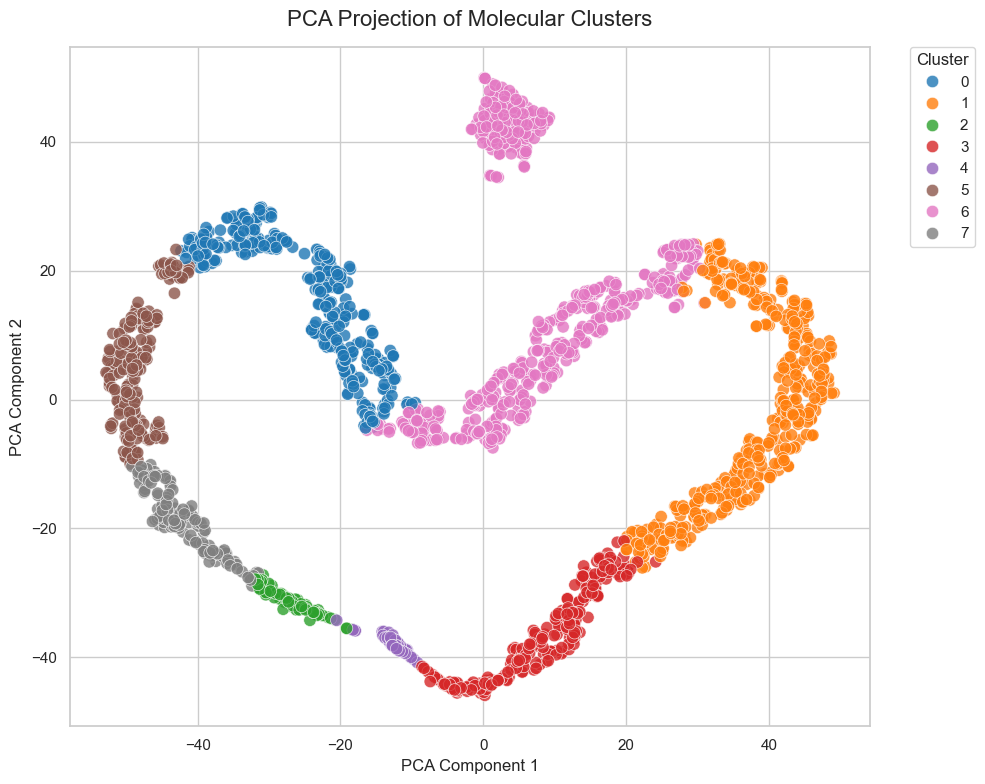


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [46]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['grassmann_svd'], num_clusters=8)

In [43]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

2 clusters:
- cluster 0: split in 2:
    - top left: small molecules. (avg is 92. almost all of these are smaller.) all of htem have nitrogen and oxygen.
    - bottom right: mostly acyclic. also some cyclic. no aromatic. many alcohol.
- cluste 1: aromatic molecules. also acyclic. 

# Riemann

Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,309,"[""qm9_31"", ""qm9_32"", ""qm9_33"", ""qm9_35"", ""qm9_36"", ""qm9_37"", ""qm9_55"", ""qm9_56"", ""qm9_57"", ""qm9_59"", ""qm9_67"", ""qm9_72"", ""qm9_75"", ""qm9_76"", ""qm9_103"", ""qm9_106"", ""qm9_113"", ""qm9_137"", ""qm9_140"", ""qm9_174"", ""qm9_184"", ""qm9_185"", ""qm9_186"", ""qm9_187"", ""qm9_188"", ""qm9_189"", ""qm9_191"", ""qm9_192"", ""qm9_193"", ""qm9_194"", ""qm9_195"", ""qm9_196"", ""qm9_197"", ""qm9_198"", ""qm9_199"", ""qm9_200"", ""qm9_201"", ""qm9_202"", ""qm9_203"", ""qm9_204"", ""qm9_205"", ""qm9_226"", ""qm9_241"", ""qm9_242"", ""qm9_273"", ""qm9_314"", ""qm9_320"", ""qm9_322"", ""qm9_328"", … ""qm9_2091""]","""[H]N([H])C([H])([H])C#N""",309
1,665,"[""qm9_8"", ""qm9_10"", ""qm9_17"", ""qm9_21"", ""qm9_29"", ""qm9_34"", ""qm9_40"", ""qm9_43"", ""qm9_47"", ""qm9_54"", ""qm9_62"", ""qm9_65"", ""qm9_69"", ""qm9_77"", ""qm9_80"", ""qm9_81"", ""qm9_83"", ""qm9_84"", ""qm9_86"", ""qm9_92"", ""qm9_93"", ""qm9_94"", ""qm9_97"", ""qm9_98"", ""qm9_99"", ""qm9_104"", ""qm9_119"", ""qm9_124"", ""qm9_130"", ""qm9_131"", ""qm9_132"", ""qm9_139"", ""qm9_141"", ""qm9_146"", ""qm9_148"", ""qm9_149"", ""qm9_154"", ""qm9_160"", ""qm9_177"", ""qm9_215"", ""qm9_216"", ""qm9_217"", ""qm9_218"", ""qm9_220"", ""qm9_223"", ""qm9_224"", ""qm9_229"", ""qm9_230"", ""qm9_231"", … ""qm9_2235""]","""[H]C#CC([H])([H])[H]""",665
2,85,"[""qm9_1"", ""qm9_2"", ""qm9_3"", ""qm9_4"", ""qm9_5"", ""qm9_24"", ""qm9_25"", ""qm9_26"", ""qm9_27"", ""qm9_49"", ""qm9_50"", ""qm9_51"", ""qm9_52"", ""qm9_110"", ""qm9_162"", ""qm9_163"", ""qm9_164"", ""qm9_165"", ""qm9_167"", ""qm9_168"", ""qm9_169"", ""qm9_170"", ""qm9_171"", ""qm9_172"", ""qm9_173"", ""qm9_181"", ""qm9_182"", ""qm9_183"", ""qm9_208"", ""qm9_209"", ""qm9_210"", ""qm9_211"", ""qm9_311"", ""qm9_312"", ""qm9_313"", ""qm9_474"", ""qm9_476"", ""qm9_711"", ""qm9_712"", ""qm9_713"", ""qm9_714"", ""qm9_715"", ""qm9_760"", ""qm9_761"", ""qm9_762"", ""qm9_763"", ""qm9_764"", ""qm9_765"", ""qm9_884"", … ""qm9_2062""]","""[H]N([H])[H]""",85
3,162,"[""qm9_0"", ""qm9_6"", ""qm9_9"", ""qm9_12"", ""qm9_15"", ""qm9_16"", ""qm9_20"", ""qm9_30"", ""qm9_38"", ""qm9_42"", ""qm9_46"", ""qm9_53"", ""qm9_61"", ""qm9_79"", ""qm9_82"", ""qm9_91"", ""qm9_96"", ""qm9_101"", ""qm9_111"", ""qm9_115"", ""qm9_117"", ""qm9_118"", ""qm9_129"", ""qm9_135"", ""qm9_138"", ""qm9_145"", ""qm9_152"", ""qm9_155"", ""qm9_158"", ""qm9_213"", ""qm9_222"", ""qm9_227"", ""qm9_243"", ""qm9_244"", ""qm9_266"", ""qm9_281"", ""qm9_284"", ""qm9_291"", ""qm9_301"", ""qm9_306"", ""qm9_361"", ""qm9_362"", ""qm9_388"", ""qm9_389"", ""qm9_404"", ""qm9_422"", ""qm9_449"", ""qm9_452"", ""qm9_456"", … ""qm9_2233""]","""[H]C([H])([H])[H]""",162
4,778,"[""qm9_7"", ""qm9_11"", ""qm9_13"", ""qm9_14"", ""qm9_18"", ""qm9_19"", ""qm9_23"", ""qm9_39"", ""qm9_41"", ""qm9_44"", ""qm9_45"", ""qm9_48"", ""qm9_58"", ""qm9_63"", ""qm9_64"", ""qm9_66"", ""qm9_68"", ""qm9_70"", ""qm9_71"", ""qm9_73"", ""qm9_74"", ""qm9_78"", ""qm9_85"", ""qm9_87"", ""qm9_88"", ""qm9_89"", ""qm9_90"", ""qm9_100"", ""qm9_107"", ""qm9_108"", ""qm9_109"", ""qm9_112"", ""qm9_114"", ""qm9_116"", ""qm9_120"", ""qm9_121"", ""qm9_122"", ""qm9_123"", ""qm9_125"", ""qm9_126"", ""qm9_127"", ""qm9_128"", ""qm9_134"", ""qm9_136"", ""qm9_143"", ""qm9_147"", ""qm9_150"", ""qm9_151"", ""qm9_153"", … ""qm9_2232""]","""[H]OC([H])([H])[H]""",778



Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,309,6.537217,0.450721,0.576661,0.01907,0.2544,0.024698,0.16894,0.014126,0.0,0.0,2.734912,2.218724,6.313376,0.594846,21.850466,10.52885,-8719.262209,1.0547e6,-6.194967,0.902845,0.118303,1.325443
1,665,6.61203,0.424554,0.789481,0.006329,0.061625,0.009937,0.148894,0.006225,0.0,0.0,2.236915,1.249448,7.770455,1.441858,26.456235,17.120627,-8180.011083,807691.879345,-6.783422,0.219913,0.986971,1.412271
2,85,5.894118,1.976751,0.550168,0.045324,0.282773,0.047538,0.167059,0.028211,0.0,0.0,2.91254,3.21805,6.071628,1.42825,16.315859,18.127734,-7831.59855,3.5149e6,-7.148079,1.091457,-1.076418,1.607151
3,162,6.197531,1.178131,0.966093,0.00886,0.031849,0.008306,0.002058,0.000686,0.0,0.0,0.85379,2.042668,9.052019,1.621091,25.822679,32.362155,-6686.370446,1.3445e6,-7.332494,0.77875,1.719474,0.615258
4,778,6.602828,0.471395,0.621426,0.009844,0.12059,0.013742,0.253743,0.011391,0.004242,0.002414,2.732659,2.041227,7.169459,1.562145,24.594557,14.321377,-9050.727201,1.2019e6,-6.921755,0.341942,0.247655,1.609088


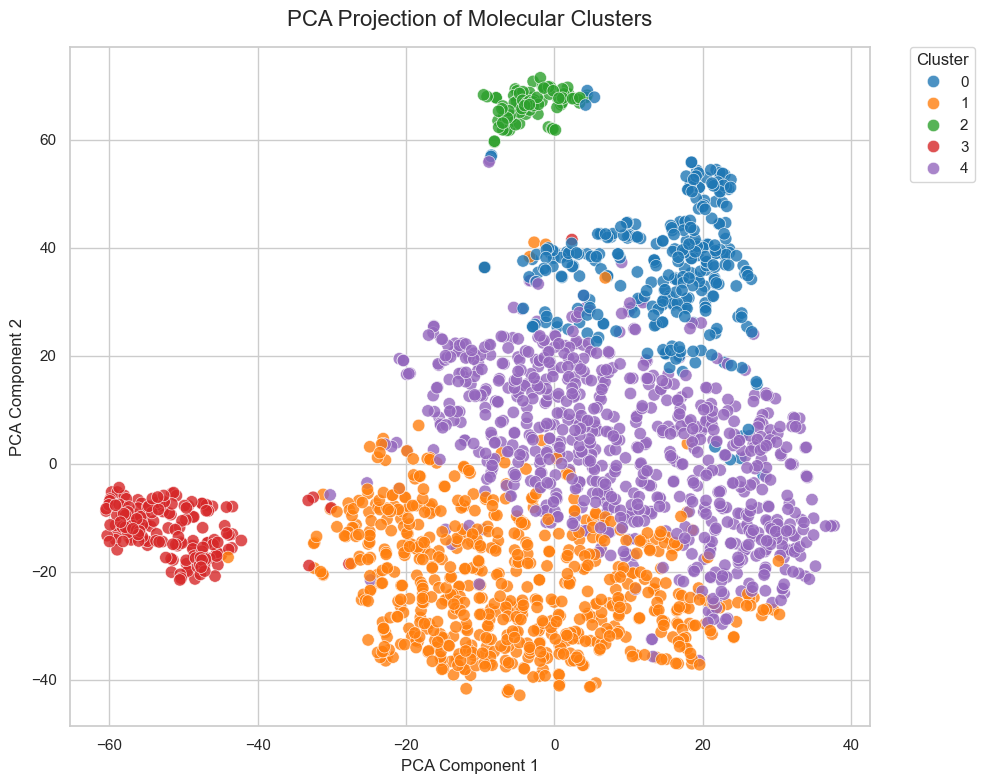


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [ ]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['euclidean_riemann'], num_clusters=5)

In [ ]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

- riemann makes clear cluster with aromatic structures when using 2 clusters
- 5 clusters:
    - cluster 0: cyclic (or acyclic) no functional groups. fairly complex molecules
    - cluster 1: aromatic
    - cluster 2: a lot of functional groups. many alcohol. many containing flour.
    - cluster 3: rings, containing nitrogen. many phenol groups. many amine. 
    - cluster 4: large diverse cluster. 

Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,157,"[""qm9_0"", ""qm9_6"", ""qm9_12"", ""qm9_15"", ""qm9_20"", ""qm9_38"", ""qm9_42"", ""qm9_46"", ""qm9_53"", ""qm9_61"", ""qm9_79"", ""qm9_82"", ""qm9_91"", ""qm9_96"", ""qm9_101"", ""qm9_111"", ""qm9_115"", ""qm9_117"", ""qm9_118"", ""qm9_129"", ""qm9_135"", ""qm9_145"", ""qm9_152"", ""qm9_155"", ""qm9_158"", ""qm9_213"", ""qm9_222"", ""qm9_227"", ""qm9_243"", ""qm9_244"", ""qm9_266"", ""qm9_281"", ""qm9_284"", ""qm9_291"", ""qm9_301"", ""qm9_306"", ""qm9_361"", ""qm9_362"", ""qm9_388"", ""qm9_389"", ""qm9_404"", ""qm9_422"", ""qm9_449"", ""qm9_452"", ""qm9_456"", ""qm9_463"", ""qm9_468"", ""qm9_495"", ""qm9_501"", … ""qm9_2233""]","""[H]C([H])([H])[H]""",157
1,75,"[""qm9_1"", ""qm9_2"", ""qm9_3"", ""qm9_4"", ""qm9_5"", ""qm9_26"", ""qm9_27"", ""qm9_49"", ""qm9_52"", ""qm9_110"", ""qm9_162"", ""qm9_163"", ""qm9_164"", ""qm9_165"", ""qm9_167"", ""qm9_168"", ""qm9_170"", ""qm9_171"", ""qm9_173"", ""qm9_181"", ""qm9_182"", ""qm9_183"", ""qm9_188"", ""qm9_204"", ""qm9_208"", ""qm9_209"", ""qm9_210"", ""qm9_211"", ""qm9_313"", ""qm9_711"", ""qm9_712"", ""qm9_713"", ""qm9_714"", ""qm9_715"", ""qm9_761"", ""qm9_762"", ""qm9_763"", ""qm9_764"", ""qm9_765"", ""qm9_770"", ""qm9_872"", ""qm9_884"", ""qm9_888"", ""qm9_894"", ""qm9_895"", ""qm9_896"", ""qm9_897"", ""qm9_898"", ""qm9_899"", … ""qm9_2062""]","""[H]N([H])[H]""",75
2,637,"[""qm9_8"", ""qm9_9"", ""qm9_17"", ""qm9_21"", ""qm9_29"", ""qm9_30"", ""qm9_34"", ""qm9_40"", ""qm9_47"", ""qm9_54"", ""qm9_62"", ""qm9_65"", ""qm9_69"", ""qm9_77"", ""qm9_80"", ""qm9_81"", ""qm9_83"", ""qm9_84"", ""qm9_86"", ""qm9_92"", ""qm9_93"", ""qm9_94"", ""qm9_97"", ""qm9_98"", ""qm9_99"", ""qm9_103"", ""qm9_104"", ""qm9_112"", ""qm9_119"", ""qm9_124"", ""qm9_130"", ""qm9_131"", ""qm9_132"", ""qm9_138"", ""qm9_141"", ""qm9_146"", ""qm9_148"", ""qm9_149"", ""qm9_154"", ""qm9_160"", ""qm9_177"", ""qm9_215"", ""qm9_216"", ""qm9_217"", ""qm9_218"", ""qm9_220"", ""qm9_223"", ""qm9_224"", ""qm9_229"", … ""qm9_2235""]","""[H]C#CC([H])([H])[H]""",637
3,837,"[""qm9_7"", ""qm9_10"", ""qm9_13"", ""qm9_14"", ""qm9_18"", ""qm9_19"", ""qm9_23"", ""qm9_35"", ""qm9_39"", ""qm9_41"", ""qm9_43"", ""qm9_44"", ""qm9_45"", ""qm9_48"", ""qm9_58"", ""qm9_63"", ""qm9_64"", ""qm9_66"", ""qm9_67"", ""qm9_68"", ""qm9_70"", ""qm9_71"", ""qm9_73"", ""qm9_74"", ""qm9_76"", ""qm9_78"", ""qm9_85"", ""qm9_87"", ""qm9_88"", ""qm9_89"", ""qm9_90"", ""qm9_100"", ""qm9_106"", ""qm9_107"", ""qm9_108"", ""qm9_113"", ""qm9_114"", ""qm9_116"", ""qm9_120"", ""qm9_121"", ""qm9_122"", ""qm9_123"", ""qm9_125"", ""qm9_127"", ""qm9_128"", ""qm9_134"", ""qm9_136"", ""qm9_139"", ""qm9_143"", … ""qm9_2232""]","""[H]OC([H])([H])[H]""",837
4,293,"[""qm9_11"", ""qm9_16"", ""qm9_24"", ""qm9_25"", ""qm9_31"", ""qm9_32"", ""qm9_33"", ""qm9_36"", ""qm9_37"", ""qm9_50"", ""qm9_51"", ""qm9_55"", ""qm9_56"", ""qm9_57"", ""qm9_59"", ""qm9_72"", ""qm9_75"", ""qm9_109"", ""qm9_126"", ""qm9_137"", ""qm9_140"", ""qm9_169"", ""qm9_172"", ""qm9_174"", ""qm9_184"", ""qm9_185"", ""qm9_186"", ""qm9_187"", ""qm9_189"", ""qm9_191"", ""qm9_192"", ""qm9_193"", ""qm9_194"", ""qm9_195"", ""qm9_196"", ""qm9_197"", ""qm9_198"", ""qm9_199"", ""qm9_200"", ""qm9_201"", ""qm9_202"", ""qm9_203"", ""qm9_205"", ""qm9_226"", ""qm9_241"", ""qm9_242"", ""qm9_273"", ""qm9_311"", ""qm9_312"", … ""qm9_2091""]","""[H]C(=O)N([H])[H]""",293



Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,157,6.254777,1.037237,0.973946,0.00705,0.026054,0.00705,0.0,0.0,0.0,0.0,0.789241,1.909741,9.037283,1.657679,26.15751,28.658191,-6730.831773,1.2372e6,-7.298527,0.751796,1.738704,0.595117
1,75,5.96,2.065946,0.532889,0.043376,0.298952,0.044117,0.168159,0.029821,0.0,0.0,2.853847,3.213353,6.134498,1.46005,16.673253,20.085734,-7964.699548,3.6352e6,-6.925007,1.1936,-0.790618,1.795232
2,637,6.609105,0.439728,0.79458,0.006109,0.062335,0.010187,0.143085,0.006114,0.0,0.0,2.232331,1.323366,7.791,1.462525,26.537732,17.176973,-8143.410409,847162.279854,-6.773943,0.26186,1.016967,1.405776
3,837,6.600956,0.474545,0.626728,0.009913,0.121429,0.014314,0.247901,0.011578,0.003943,0.002245,2.734912,2.00864,7.156013,1.514432,24.54254,14.147825,-9009.208929,1.2033e6,-6.90161,0.345141,0.254363,1.543597
4,293,6.467577,0.571719,0.567707,0.018788,0.255119,0.025702,0.177174,0.01462,0.0,0.0,2.714878,2.144073,6.304265,0.760577,21.31745,13.083477,-8676.27879,1.2660e6,-6.310246,1.0537,-0.006018,1.585302


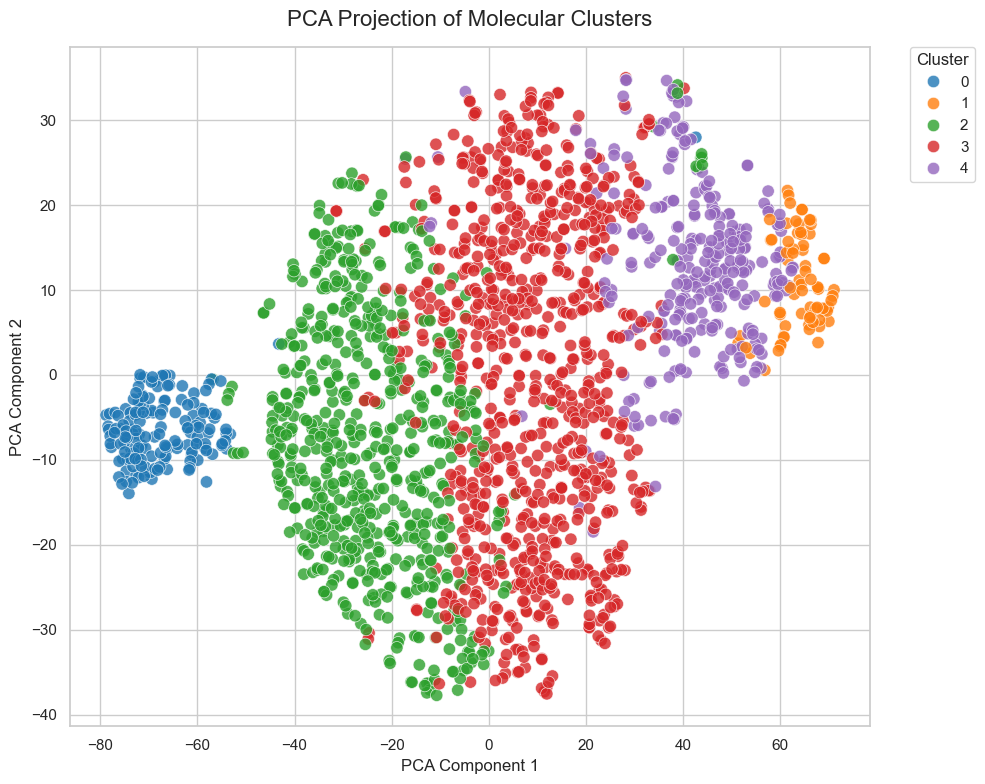


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [ ]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['affine_riemann'], num_clusters=5)

In [ ]:
chemiscope.show_input(output_path)


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

5 clusters:
- cluster 0: many flour. majority aromatic with phenol group in the middle of the cluster. on the left: acyclic flour with functional groups. on the right: aromatic phenol.
- cluster 1: many ether and ketone in top. on the right: alcohol. middle: cyclic ether.
- cluster 2: cyclic/acyclic no functional groups. almost only carbon and hydrogen.
- cluster 3: aromatic. few functional groups.
- cluster 4: acyclic. top: many functional groups and flour. bottom: cyclic ether some alcohol. left acyclic alcohol. right: like left on cluster 0.

# Earths movers distance

Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1134,"[""qm9_0"", ""qm9_1"", ""qm9_2"", ""qm9_3"", ""qm9_4"", ""qm9_5"", ""qm9_7"", ""qm9_8"", ""qm9_9"", ""qm9_10"", ""qm9_12"", ""qm9_15"", ""qm9_18"", ""qm9_19"", ""qm9_20"", ""qm9_21"", ""qm9_26"", ""qm9_27"", ""qm9_29"", ""qm9_30"", ""qm9_31"", ""qm9_33"", ""qm9_34"", ""qm9_35"", ""qm9_36"", ""qm9_37"", ""qm9_39"", ""qm9_45"", ""qm9_46"", ""qm9_47"", ""qm9_48"", ""qm9_49"", ""qm9_50"", ""qm9_51"", ""qm9_52"", ""qm9_55"", ""qm9_56"", ""qm9_57"", ""qm9_58"", ""qm9_59"", ""qm9_61"", ""qm9_62"", ""qm9_63"", ""qm9_64"", ""qm9_65"", ""qm9_66"", ""qm9_67"", ""qm9_68"", ""qm9_69"", … ""qm9_2228""]","""[H]C([H])([H])[H]""",1134
1,865,"[""qm9_6"", ""qm9_11"", ""qm9_13"", ""qm9_14"", ""qm9_16"", ""qm9_17"", ""qm9_23"", ""qm9_24"", ""qm9_25"", ""qm9_32"", ""qm9_38"", ""qm9_40"", ""qm9_41"", ""qm9_42"", ""qm9_43"", ""qm9_44"", ""qm9_53"", ""qm9_54"", ""qm9_71"", ""qm9_73"", ""qm9_74"", ""qm9_84"", ""qm9_91"", ""qm9_92"", ""qm9_93"", ""qm9_96"", ""qm9_97"", ""qm9_98"", ""qm9_99"", ""qm9_100"", ""qm9_101"", ""qm9_104"", ""qm9_107"", ""qm9_108"", ""qm9_109"", ""qm9_111"", ""qm9_114"", ""qm9_116"", ""qm9_120"", ""qm9_122"", ""qm9_123"", ""qm9_128"", ""qm9_129"", ""qm9_132"", ""qm9_134"", ""qm9_135"", ""qm9_136"", ""qm9_137"", ""qm9_139"", … ""qm9_2235""]","""[H]C([H])([H])C([H])([H])[H]""",865



Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1134,6.510582,0.682589,0.66603,0.026152,0.155274,0.025288,0.178695,0.01565,0.0,0.0,2.618228,2.023761,7.026388,1.699239,23.456131,21.906756,-8487.097743,1.6339e6,-6.732675,0.676181,0.293593,1.629184
1,865,6.56185,0.49646,0.733705,0.022274,0.076906,0.011462,0.185574,0.014016,0.003815,0.002173,2.168155,2.144527,7.757938,1.887254,25.95448,17.689249,-8439.230293,1.5531e6,-6.902824,0.355917,0.855136,1.772494


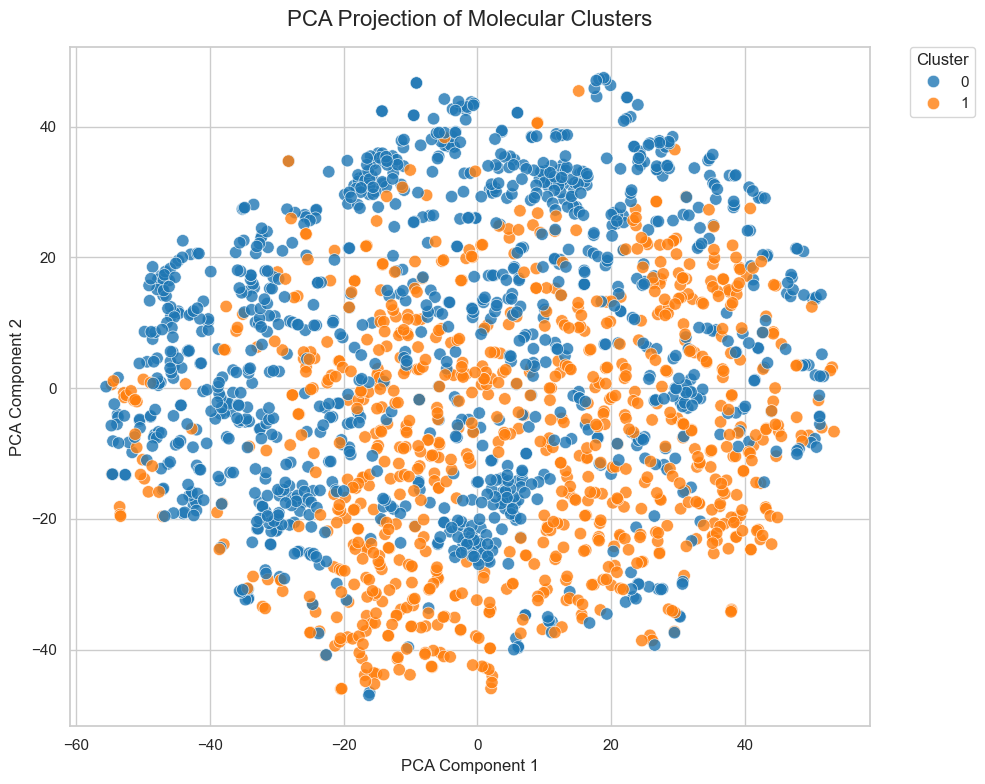


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [ ]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['wasserstein'], num_clusters=2)


In [ ]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

2 clusters:
- cluster 0: not very well seperated. no idea.

# Persistent homology

Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,118,"[""qm9_53"", ""qm9_79"", ""qm9_129"", ""qm9_510"", ""qm9_514"", ""qm9_1056"", ""qm9_1059"", ""qm9_1063"", ""qm9_1064"", ""qm9_1073"", ""qm9_1093"", ""qm9_1094"", ""qm9_1096"", ""qm9_1116"", ""qm9_1135"", ""qm9_1144"", ""qm9_1145"", ""qm9_1147"", ""qm9_1148"", ""qm9_1150"", ""qm9_1153"", ""qm9_1154"", ""qm9_1156"", ""qm9_1166"", ""qm9_1208"", ""qm9_1209"", ""qm9_1211"", ""qm9_1216"", ""qm9_1217"", ""qm9_1218"", ""qm9_1234"", ""qm9_1236"", ""qm9_1237"", ""qm9_1243"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1265"", ""qm9_1281"", ""qm9_1282"", ""qm9_1290"", ""qm9_1297"", ""qm9_1298"", ""qm9_1319"", ""qm9_1324"", ""qm9_1390"", ""qm9_1425"", ""qm9_1428"", ""qm9_1429"", … ""qm9_2228""]","""[H]C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",118
1,162,"[""qm9_20"", ""qm9_38"", ""qm9_116"", ""qm9_178"", ""qm9_215"", ""qm9_216"", ""qm9_228"", ""qm9_245"", ""qm9_251"", ""qm9_253"", ""qm9_257"", ""qm9_277"", ""qm9_280"", ""qm9_288"", ""qm9_290"", ""qm9_295"", ""qm9_296"", ""qm9_299"", ""qm9_309"", ""qm9_310"", ""qm9_349"", ""qm9_351"", ""qm9_353"", ""qm9_359"", ""qm9_363"", ""qm9_364"", ""qm9_366"", ""qm9_367"", ""qm9_374"", ""qm9_376"", ""qm9_378"", ""qm9_387"", ""qm9_388"", ""qm9_403"", ""qm9_408"", ""qm9_409"", ""qm9_411"", ""qm9_425"", ""qm9_426"", ""qm9_469"", ""qm9_470"", ""qm9_471"", ""qm9_508"", ""qm9_511"", ""qm9_513"", ""qm9_517"", ""qm9_520"", ""qm9_522"", ""qm9_526"", … ""qm9_2230""]","""[H]C([H])([H])C([H])(C([H])([H])[H])C([H])([H])[H]""",162
2,129,"[""qm9_1055"", ""qm9_1057"", ""qm9_1061"", ""qm9_1066"", ""qm9_1071"", ""qm9_1079"", ""qm9_1090"", ""qm9_1101"", ""qm9_1107"", ""qm9_1110"", ""qm9_1111"", ""qm9_1112"", ""qm9_1114"", ""qm9_1115"", ""qm9_1142"", ""qm9_1152"", ""qm9_1155"", ""qm9_1161"", ""qm9_1162"", ""qm9_1165"", ""qm9_1206"", ""qm9_1214"", ""qm9_1233"", ""qm9_1240"", ""qm9_1254"", ""qm9_1255"", ""qm9_1260"", ""qm9_1262"", ""qm9_1274"", ""qm9_1278"", ""qm9_1280"", ""qm9_1295"", ""qm9_1300"", ""qm9_1301"", ""qm9_1303"", ""qm9_1305"", ""qm9_1308"", ""qm9_1313"", ""qm9_1314"", ""qm9_1317"", ""qm9_1323"", ""qm9_1427"", ""qm9_1432"", ""qm9_1445"", ""qm9_1475"", ""qm9_1483"", ""qm9_1501"", ""qm9_1519"", ""qm9_1527"", … ""qm9_2211""]","""[H]C([H])([H])C#CC(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",129
3,54,"[""qm9_17"", ""qm9_23"", ""qm9_29"", ""qm9_34"", ""qm9_41"", ""qm9_43"", ""qm9_45"", ""qm9_47"", ""qm9_64"", ""qm9_75"", ""qm9_76"", ""qm9_87"", ""qm9_89"", ""qm9_121"", ""qm9_123"", ""qm9_136"", ""qm9_138"", ""qm9_232"", ""qm9_241"", ""qm9_242"", ""qm9_273"", ""qm9_274"", ""qm9_319"", ""qm9_320"", ""qm9_322"", ""qm9_327"", ""qm9_332"", ""qm9_339"", ""qm9_346"", ""qm9_347"", ""qm9_479"", ""qm9_484"", ""qm9_488"", ""qm9_489"", ""qm9_494"", ""qm9_503"", ""qm9_506"", ""qm9_690"", ""qm9_791"", ""qm9_815"", ""qm9_1169"", ""qm9_1172"", ""qm9_1327"", ""qm9_1331"", ""qm9_1334"", ""qm9_1337"", ""qm9_1339"", ""qm9_1344"", ""qm9_1345"", … ""qm9_1889""]","""[H]C([H])([H])C(=O)C([H])([H])[H]""",54
4,123,"[""qm9_155"", ""qm9_177"", ""qm9_453"", ""qm9_802"", ""qm9_809"", ""qm9_819"", ""qm9_820"", ""qm9_824"", ""qm9_830"", ""qm9_848"", ""qm9_849"", ""qm9_879"", ""qm9_904"", ""qm9_934"", ""qm9_935"", ""qm9_937"", ""qm9_940"", ""qm9_963"", ""qm9_970"", ""qm9_972"", ""qm9_974"", ""qm9_1011"", ""qm9_1013"", ""qm9_1015"", ""qm9_1035"", ""qm9_1036"", ""qm9_1038"", ""qm9_1105"", ""qm9_1106"", ""qm9_1266"", ""qm9_1268"", ""qm9_1270"", ""qm9_1272"", ""qm9_1647"", ""qm9_1648"", ""qm9_1652"", ""qm9_1655"", ""qm9_1661"", ""qm9_1663"", ""qm9_1784"", ""qm9_1785"", ""qm9_1792"", ""qm9_1795"", ""qm9_1799"", ""qm9_1801"", ""qm9_1807"", ""qm9_1811"", ""qm9_1815"", ""qm9_1817"", … ""qm9_2231""]","""[H]C1([H])C([H])([H])C([H])([H])C([H])([H])C1([H])[H]""",123
5,70,"[""qm9_12"", ""qm9_62"", ""qm9_63"", ""qm9_66"", ""qm9_68"", ""qm9_72"", ""qm9_74"", ""qm9_85"", ""qm9_100"", ""qm9_114"", ""qm9_119"", ""qm9_120"", ""qm9_1


Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,118,6.932203,0.115022,0.747377,0.011493,0.045198,0.008008,0.207425,0.01098,0.0,0.0,2.276137,1.037811,7.719086,1.266421,29.521449,3.301843,-8951.710731,754694.251718,-6.854271,0.172882,0.864676,1.035294
1,162,6.481481,0.338164,0.687272,0.016484,0.122781,0.013977,0.189947,0.013183,0.0,0.0,2.738046,1.574472,7.440114,1.377607,25.039586,6.662751,-8460.042363,1.2590e6,-6.945622,0.235089,0.494525,1.339498
2,129,7.0,0.0,0.860465,0.009715,0.009967,0.001335,0.129568,0.008751,0.0,0.0,1.258928,0.608734,8.47757,0.857372,30.369612,4.049458,-8396.501276,441812.845737,-6.721993,0.112473,1.755641,0.619698
3,54,5.814815,1.021663,0.59515,0.022816,0.145106,0.014938,0.250485,0.021113,0.009259,0.00463,3.030069,3.25323,6.723984,2.657524,20.323778,9.69117,-8077.222937,3.1700e6,-7.372068,0.434808,-0.648236,2.589421
4,123,6.96748,0.048114,0.72048,0.009366,0.086334,0.015022,0.193186,0.012678,0.0,0.0,2.396865,1.324941,7.028745,1.151594,24.763455,2.049178,-8984.004589,482964.260093,-6.47173,0.42115,0.557037,0.926445
5,70,5.985714,0.680952,0.632993,0.020207,0.152993,0.02072,0.214014,0.016302,0.0,0.0,3.076964,2.173834,6.780455,2.157443,21.811371,5.528683,-8010.681616,1.7970e6,-7.2965,0.311547,-0.516083,1.745215
6,131,6.396947,0.518144,0.642639,0.017798,0.134206,0.014619,0.223155,0.015407,0.0,0.0,3.056427,3.130095,7.119703,1.754817,24.387725,7.255429,-8599.494163,1.8981e6,-7.049058,0.266031,0.070646,1.490524
7,25,5.12,1.36,0.635524,0.035499,0.126952,0.022941,0.217524,0.018291,0.02,0.01,2.8395,1.928273,7.152785,2.592923,17.84456,9.074524,-7028.849697,4.5065e6,-7.600575,0.534349,-0.447573,2.96191
8,144,6.583333,0.258741,0.730159,0.017705,0.09995,0.008097,0.169891,0.010734,0.0,0.0,2.511267,3.088291,7.99,1.258426,27.136965,5.193185,-8425.577393,1.2872e6,-6.843985,0.244328,1.145713,0.923798


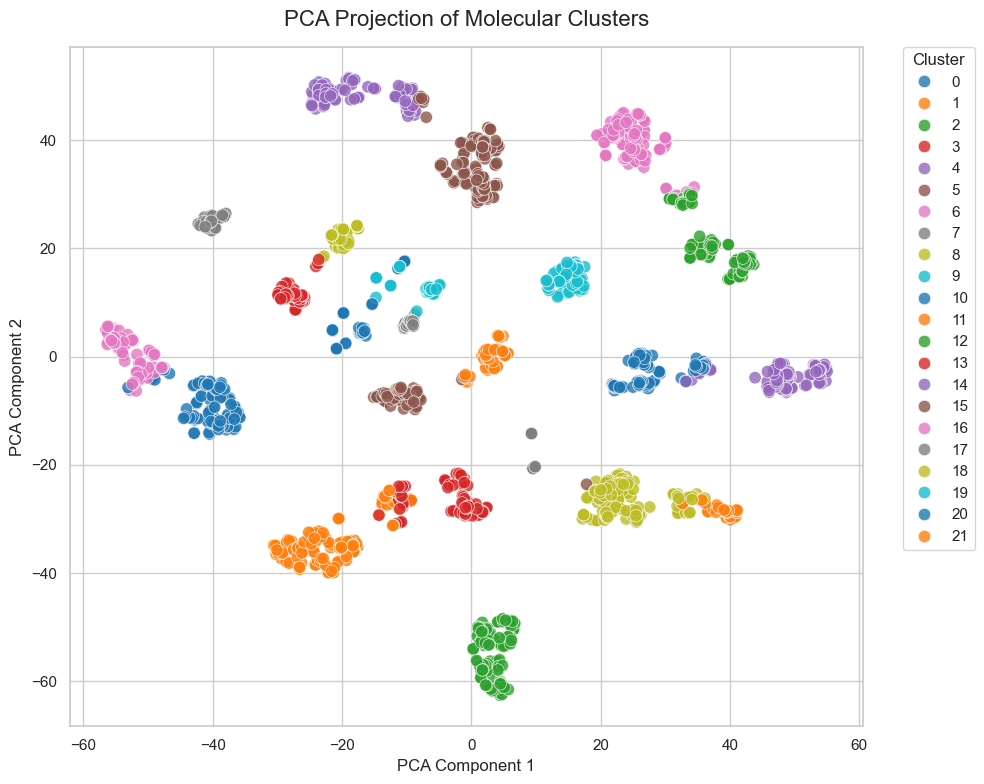


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [ ]:
summary_table, profile_table, output_path = make_clustering(
    frames, 
    dist_matrix=distance_matrices['ph_bottleneck'],
    num_clusters=22
)

In [ ]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

22 cluster - very well seperated:
- cluster 0: acyclic. amide.
- cluster 1: cyclic. amide, ether. complicated looking molecules.
- cluster 2: acyclic. amine. ether. alcohol.
- cluster 3: cyclic. alcohol. top right: acyclic no functional groups.
- cluster 4: either aromatic or cyclic. amine, phenol. cyclic with amide, ketone, ester, ether.
- cluster 5: middle: aromatic. top cyclic ether. bottom cyclic ketone and alcohol, ester ether.
- cluster 6: acyclic all different kinds of functional groups.
- cluster 7: acyclic, on the right cyclic
- cluster 8: top: aromatic, middle right: cyclic many functional groups. left: cyclic alcohol.

Using precomputed euclidean distance matrix (Shape: (1999, 1999))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,212,"[""qm9_222"", ""qm9_266"", ""qm9_268"", ""qm9_281"", ""qm9_284"", ""qm9_294"", ""qm9_301"", ""qm9_382"", ""qm9_383"", ""qm9_404"", ""qm9_422"", ""qm9_456"", ""qm9_463"", ""qm9_465"", ""qm9_533"", ""qm9_553"", ""qm9_580"", ""qm9_607"", ""qm9_609"", ""qm9_611"", ""qm9_624"", ""qm9_648"", ""qm9_794"", ""qm9_1055"", ""qm9_1057"", ""qm9_1061"", ""qm9_1065"", ""qm9_1066"", ""qm9_1067"", ""qm9_1068"", ""qm9_1069"", ""qm9_1070"", ""qm9_1071"", ""qm9_1076"", ""qm9_1077"", ""qm9_1078"", ""qm9_1079"", ""qm9_1090"", ""qm9_1099"", ""qm9_1100"", ""qm9_1101"", ""qm9_1107"", ""qm9_1109"", ""qm9_1110"", ""qm9_1111"", ""qm9_1112"", ""qm9_1113"", ""qm9_1114"", ""qm9_1115"", … ""qm9_2211""]","""[H]C([H])([H])C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",212
1,262,"[""qm9_20"", ""qm9_38"", ""qm9_116"", ""qm9_178"", ""qm9_215"", ""qm9_216"", ""qm9_228"", ""qm9_245"", ""qm9_251"", ""qm9_253"", ""qm9_257"", ""qm9_277"", ""qm9_280"", ""qm9_288"", ""qm9_290"", ""qm9_295"", ""qm9_296"", ""qm9_299"", ""qm9_305"", ""qm9_309"", ""qm9_310"", ""qm9_349"", ""qm9_351"", ""qm9_353"", ""qm9_359"", ""qm9_363"", ""qm9_364"", ""qm9_366"", ""qm9_367"", ""qm9_374"", ""qm9_376"", ""qm9_378"", ""qm9_387"", ""qm9_388"", ""qm9_403"", ""qm9_408"", ""qm9_409"", ""qm9_411"", ""qm9_425"", ""qm9_426"", ""qm9_435"", ""qm9_438"", ""qm9_447"", ""qm9_451"", ""qm9_454"", ""qm9_455"", ""qm9_459"", ""qm9_460"", ""qm9_462"", … ""qm9_2230""]","""[H]C([H])([H])C([H])(C([H])([H])[H])C([H])([H])[H]""",262
2,197,"[""qm9_12"", ""qm9_21"", ""qm9_39"", ""qm9_40"", ""qm9_42"", ""qm9_44"", ""qm9_46"", ""qm9_48"", ""qm9_61"", ""qm9_62"", ""qm9_63"", ""qm9_66"", ""qm9_67"", ""qm9_68"", ""qm9_70"", ""qm9_71"", ""qm9_72"", ""qm9_74"", ""qm9_85"", ""qm9_86"", ""qm9_100"", ""qm9_114"", ""qm9_118"", ""qm9_119"", ""qm9_120"", ""qm9_122"", ""qm9_125"", ""qm9_126"", ""qm9_127"", ""qm9_128"", ""qm9_135"", ""qm9_138"", ""qm9_141"", ""qm9_150"", ""qm9_151"", ""qm9_160"", ""qm9_174"", ""qm9_225"", ""qm9_226"", ""qm9_229"", ""qm9_230"", ""qm9_231"", ""qm9_233"", ""qm9_234"", ""qm9_235"", ""qm9_236"", ""qm9_238"", ""qm9_239"", ""qm9_240"", … ""qm9_1894""]","""[H]C([H])([H])C([H])([H])C([H])([H])[H]""",197
3,264,"[""qm9_54"", ""qm9_77"", ""qm9_80"", ""qm9_81"", ""qm9_82"", ""qm9_91"", ""qm9_96"", ""qm9_98"", ""qm9_130"", ""qm9_131"", ""qm9_132"", ""qm9_145"", ""qm9_147"", ""qm9_155"", ""qm9_176"", ""qm9_177"", ""qm9_244"", ""qm9_247"", ""qm9_249"", ""qm9_255"", ""qm9_256"", ""qm9_276"", ""qm9_279"", ""qm9_350"", ""qm9_362"", ""qm9_377"", ""qm9_402"", ""qm9_453"", ""qm9_516"", ""qm9_525"", ""qm9_583"", ""qm9_605"", ""qm9_628"", ""qm9_802"", ""qm9_809"", ""qm9_819"", ""qm9_820"", ""qm9_824"", ""qm9_830"", ""qm9_848"", ""qm9_849"", ""qm9_879"", ""qm9_904"", ""qm9_934"", ""qm9_935"", ""qm9_937"", ""qm9_940"", ""qm9_963"", ""qm9_970"", … ""qm9_2235""]","""[H]OC(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",264
4,96,"[""qm9_0"", ""qm9_1"", ""qm9_2"", ""qm9_3"", ""qm9_4"", ""qm9_5"", ""qm9_6"", ""qm9_7"", ""qm9_8"", ""qm9_9"", ""qm9_10"", ""qm9_11"", ""qm9_13"", ""qm9_14"", ""qm9_15"", ""qm9_16"", ""qm9_18"", ""qm9_19"", ""qm9_24"", ""qm9_25"", ""qm9_26"", ""qm9_27"", ""qm9_30"", ""qm9_31"", ""qm9_32"", ""qm9_33"", ""qm9_35"", ""qm9_36"", ""qm9_37"", ""qm9_52"", ""qm9_55"", ""qm9_56"", ""qm9_57"", ""qm9_58"", ""qm9_59"", ""qm9_88"", ""qm9_90"", ""qm9_103"", ""qm9_104"", ""qm9_106"", ""qm9_107"", ""qm9_108"", ""qm9_109"", ""qm9_110"", ""qm9_111"", ""qm9_112"", ""qm9_113"", ""qm9_137"", ""qm9_139"", … ""qm9_1338""]","""[H]C([H])([H])[H]""",96
5,261,"[""qm9_53"", ""qm9_79"", ""qm9_129"", ""qm9_220"", ""qm9_223"", ""qm9_224"", ""qm9_264"", ""qm9_267"", ""qm9_269"", ""qm9_282"", ""qm9_384"", ""qm9_510"", ""qm9_514"", ""qm9_535"", ""qm9_536"", ""qm9_578"", ""qm9_626"", ""qm9_782"", ""qm9_786"", ""qm9_788"", ""qm9_789"", ""qm9_796"", ""qm9_797"", ""qm9_803"", ""qm9_1056"", ""qm9_1058"", ""qm9_1059""


Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,212,6.896226,0.093445,0.87646,0.009706,0.020777,0.002643,0.102763,0.008452,0.0,0.0,1.131691,0.783432,8.773503,0.936607,30.678755,6.713672,-8137.503911,630157.299334,-6.892041,0.319287,1.881423,0.483328
1,262,6.572519,0.299319,0.695856,0.014783,0.123991,0.012583,0.180153,0.011175,0.0,0.0,2.603753,1.715631,7.275577,1.443037,24.27926,6.666497,-8510.41445,1.0816e6,-6.645706,0.531995,0.629881,1.246114
2,197,6.081218,0.615819,0.644211,0.021296,0.139703,0.019469,0.216087,0.017015,0.0,0.0,2.923398,2.11124,6.954912,1.734692,22.066,7.20313,-8135.871633,2.0175e6,-7.20121,0.311262,-0.24638,1.531335
3,264,6.82197,0.253356,0.717839,0.013264,0.086111,0.014351,0.19605,0.014118,0.0,0.0,2.405804,1.474321,7.139526,1.443192,25.942208,4.738135,-8833.182965,1.0725e6,-6.707153,0.336584,0.43229,1.229054
4,96,4.791667,1.850877,0.525397,0.054796,0.23688,0.056989,0.208557,0.032642,0.029167,0.016404,2.56534,2.317645,7.215864,4.065392,14.876531,15.143884,-6817.279902,5.5255e6,-7.870808,0.981672,-0.654916,3.193119
5,261,6.923372,0.094106,0.77422,0.010119,0.050082,0.007693,0.175698,0.008991,0.0,0.0,2.076372,1.066702,7.860629,1.154402,28.43613,4.441242,-8731.698803,591296.010547,-6.719794,0.18708,1.140793,0.959035
6,190,6.626316,0.245865,0.744486,0.017365,0.10282,0.007214,0.152694,0.010863,0.0,0.0,2.347617,2.702327,7.871037,1.29547,26.50421,5.972298,-8368.019344,1.2069e6,-6.718992,0.346537,1.151844,0.850956
7,166,6.795181,0.188098,0.611274,0.012567,0.211704,0.016815,0.177022,0.012718,0.0,0.0,2.536254,1.855221,6.292797,0.981435,21.46909,5.615107,-9009.96054,921318.694854,-6.059369,0.627062,0.233379,1.465576
8,164,6.140244,0.563033,0.541347,0.020912,0.262384,0.03655,0.19322,0.019869,0.003049,0.001524,2.997334,2.604987,6.451355,1.190064,18.949549,6.646678,-8400.244998,1.6669e6,-6.796707,0.734404,-0.345419,1.618502


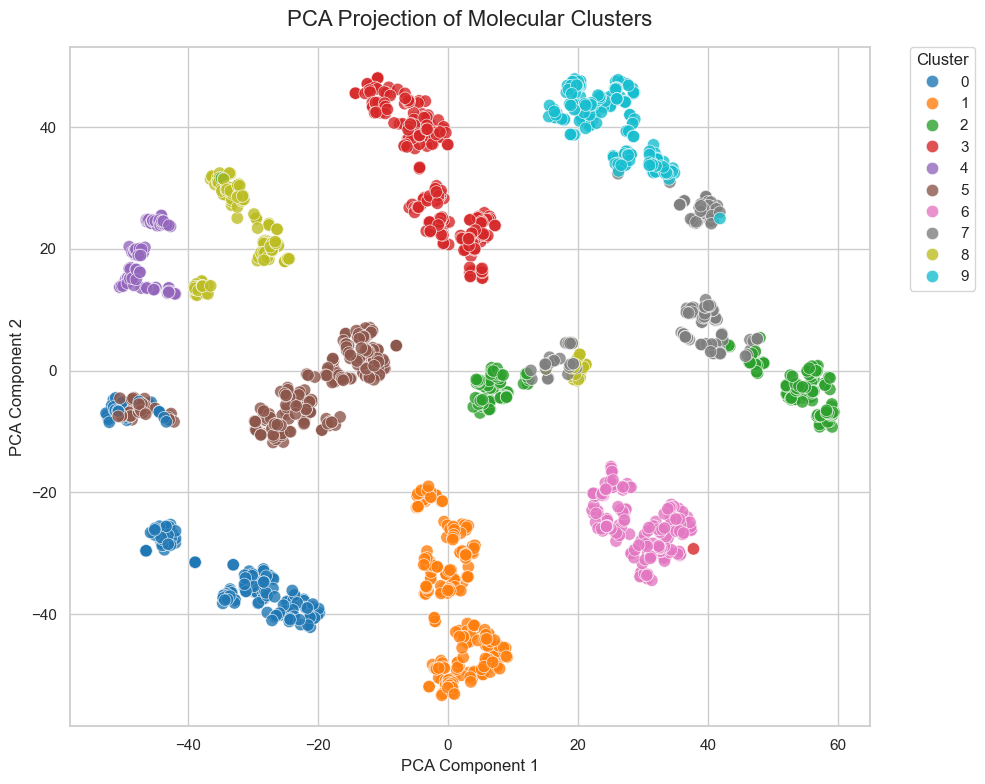


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [ ]:
summary_table, profile_table, output_path = make_clustering(
    frames, 
    dist_matrix=distance_matrices['ph_sliced_wasserstein'],
    num_clusters=10,
)

In [ ]:

chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

10 clusters:
- cluster 0: dunno.
- cluster 1: acyclic one with halogen or aromatic containing phenol.
- cluster 2: cyclic ether or ketone.
- cluster 3: cyclic/acycic alcohol also other groups, amine, amide ether.
- cluster 4: acyclic, ether, amine amide.
- cluster 5: acyclic, amide, ester ether, alcohol.
- cluster 6: cyclic, amide, ether, alcohol, 
- cluster 7: cyclic, ether, alcohol
- cluster 8: small, aromatic, amine, phenol
- cluster 9: not well defined: some aromatic some cyclic with ether.